In [ ]:
scp /Volumes/老大/NSD/nsddata_betas liancheng@202.120.22.41:32562:/home/data/lianspace

In [2]:
import os
import argparse
import numpy as np
import nibabel as nib
from tqdm import tqdm
import configparser

config = configparser.ConfigParser()
config.read("../config.cfg")
ROI_PATH = config["DATA"]["PPdataPath"]
BETA_PATH = config["DATA"]["BetaPath"]


In [2]:
subj = 1
roi = "floc-faces"
output_dir = "./test_result"

if roi != "":
        roi_tag = "_" + roi
else:
    roi_tag = ""

nsd_general_path = "%s/subj%02d/func1pt8mm/roi/nsdgeneral.nii.gz" % (
    ROI_PATH,
    subj,
)
nsd_general = nib.load(nsd_general_path)
nsd_cortical_mat = nsd_general.get_fdata()

if roi == "general" or roi == "":
    anat_mat = nsd_cortical_mat
else:
    roi_subj_path = "%s/subj%02d/func1pt8mm/roi/%s.nii.gz" % (ROI_PATH, subj, roi)
    anat = nib.load(roi_subj_path)
    anat_mat = anat.get_fdata()

if roi == "":  # cortical
    mask = anat_mat > -1
else:  # roi
    mask = anat_mat > 0

    # save a 1D version as well
    cortical = nsd_cortical_mat > -1
    print("from NSD general, cortical voxel number is: %d." % np.sum(cortical))
    roi_1d_mask = anat_mat[cortical].astype(int)
    # assert np.sum(roi_1d_mask) == np.sum(mask)
    print("Number of non-zero ROI voxels: " + str(np.sum(roi_1d_mask > 0)))
    print("Number of cortical voxels is: " + str(len(roi_1d_mask)))
    assert len(roi_1d_mask) == np.sum(
        cortical
    )  # check the roi 1D length is same as cortical numbers in nsd general
    np.save(
        "%s/voxels_masks/subj%d/roi_1d_mask_subj%02d%s.npy"
        % (output_dir, subj, subj, roi_tag),
        roi_1d_mask,
    )

from NSD general, cortical voxel number is: 107104.
Number of non-zero ROI voxels: 1308
Number of cortical voxels is: 107104


Text(0.5, 0.98, 'Center slices for EPI image')

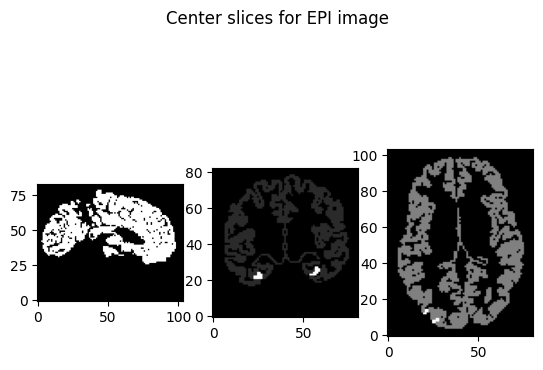

In [3]:
import matplotlib.pyplot as plt
def show_slices(slices):
   """ Function to display row of image slices """
   fig, axes = plt.subplots(1, len(slices))
   for i, slice in enumerate(slices):
       axes[i].imshow(slice.T, cmap="gray", origin="lower")

slice_0 = anat_mat[40, :, :]
slice_1 = anat_mat[:, 52, :]
slice_2 = anat_mat[:, :, 41]
show_slices([slice_0, slice_1, slice_2])
plt.suptitle("Center slices for EPI image")  

In [ ]:
def zscore_by_run(mat, run_n=480):
    from scipy.stats import zscore

    run_n = np.ceil(
        mat.shape[0] / 62.5
    )  # should be 480 for subject with full experiment\

    zscored_mat = np.zeros(mat.shape)
    index_so_far = 0
    for i in tqdm(range(int(run_n))):
        if i % 2 == 0:
            zscored_mat[index_so_far : index_so_far + 62, :] = zscore(
                mat[index_so_far : index_so_far + 62, :]
            )
            index_so_far += 62
        else:
            zscored_mat[index_so_far : index_so_far + 63, :] = zscore(
                mat[index_so_far : index_so_far + 63, :]
            )
            index_so_far += 63

    return zscored_mat


tag = roi
zscore_tag = "zscored_by_run_"


output_path = (
    "%s/cortical_voxels/cortical_voxel_across_sessions_%ssubj%02d%s_2.npy"
    % (output_dir, zscore_tag, subj, "")
)

beta_subj_dir = "%s/subj%02d/func1pt8mm/betas_fithrf_GLMdenoise_RR" % (
    BETA_PATH,
    subj,
)

mask = np.load(
    "%s/voxels_masks/subj%d/cortical_mask_subj%02d%s.npy"
    % (output_dir, subj, subj, tag)
)


cortical_beta_mat = None
for ses in tqdm(range(21, 41)):
    try:
        beta_file = nib.load("%s/betas_session%02d.nii.gz" % (beta_subj_dir, ses))
    except FileNotFoundError:
        break
    beta = beta_file.get_fdata()
    cortical_beta = (beta[mask]).T  # verify the mask with array

    if cortical_beta_mat is None:
        cortical_beta_mat = cortical_beta / 300
    else:
        cortical_beta_mat = np.vstack((cortical_beta_mat, cortical_beta / 300))

print("NaN Values:" + str(np.any(np.isnan(cortical_beta_mat))))
print("Is finite:" + str(np.all(np.isfinite(cortical_beta_mat))))


print("Zscoring...")
cortical_beta_mat = zscore_by_run(cortical_beta_mat)
finite_flag = np.all(np.isfinite(cortical_beta_mat))
print("Is finite:" + str(finite_flag))

if finite_flag == False:
    nonzero_mask = (
        np.sum(np.isfinite(cortical_beta_mat), axis=0)
        == cortical_beta_mat.shape[0]
    )
    np.save(
        "%s/voxels_masks/subj%d/nonzero_voxels_subj%02d.npy"
        % (output_dir, subj, subj),
        nonzero_mask,
    )

np.save(output_path, cortical_beta_mat)


FileNotFoundError: [Errno 2] No such file or directory: './test_result/voxels_masks/subj1/cortical_mask_subj01_floc-faces.npy'

In [10]:
face_mask = np.load(
    "%s/voxels_masks/subj%d/roi_1d_mask_subj%02d%s.npy"
    % (output_dir, subj, subj, roi_tag)
)
cortical_beta_mat = np.load(
    "%s/cortical_voxels/cortical_voxel_across_sessions_%ssubj%02d%s_1.npy"
    % (output_dir, zscore_tag, subj, "")
)

In [12]:
face_mask.shape

(107104,)

In [ ]:
cortical_beta_mat.shape


(15000, 107104)

In [15]:
face_mask_beta = cortical_beta_mat[:,face_mask]

: 